## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [11]:
# If you didn't download it yet, please get the relevant file now!
#!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/
filename = "~/data/data_000637.txt"

In [12]:
import pandas as pd

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

In [13]:
df = pd.read_csv(filename, nrows=50000)
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25
...,...,...,...,...,...,...
49995,1,1,2,3869200664,1103,4
49996,1,1,4,3869200664,1105,14
49997,1,0,59,3869200664,1191,17
49998,1,0,32,3869200664,1191,1


2\. Find out the number of BX in a ORBIT (the value 'x').

In [14]:
# "x" corresponds to the max value of bxs, because it's not guaranteed that every ORBIT_CNT
# reaches that value, so we can't use just a "for" loop
bxs = df["BX_COUNTER"].values
x = bxs.max()

print(f"Number of BX in a ORBIT: {x}")

Number of BX in a ORBIT: 3563


3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

In [15]:
whole_df = pd.read_csv(filename)
whole_orbit = whole_df["ORBIT_CNT"]
time = ( whole_orbit.max() - whole_orbit.min() ) * x * 25     # ns

print(f"Measurement lasted {time * 10 ** (-9)}s")

Measurement lasted 0.9801813s


4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

In [16]:
import numpy as np

times = np.zeros(len(bxs))
for i in range(1, len(bxs)):
    prev_time = times[i-1]
    times[i] = prev_time + abs((bxs[i]-bxs[i-1])*25)

df["Absolute time [ns]"] = pd.Series(times, index=df.index)
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,Absolute time [ns]
0,1,0,123,3869200167,2374,26,0.0
1,1,0,124,3869200167,2374,27,0.0
2,1,0,63,3869200167,2553,28,4475.0
3,1,0,64,3869200167,2558,19,4600.0
4,1,0,64,3869200167,2760,25,9650.0
...,...,...,...,...,...,...,...
49995,1,1,2,3869200664,1103,4,78942475.0
49996,1,1,4,3869200664,1105,14,78942525.0
49997,1,0,59,3869200664,1191,17,78944675.0
49998,1,0,32,3869200664,1191,1,78944675.0


5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

In [17]:
rnd_values = np.random.randint(0, 2, len(bxs))
df["HEAD"] = pd.Series(rnd_values, index=df.index)
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,Absolute time [ns]
0,1,0,123,3869200167,2374,26,0.0
1,1,0,124,3869200167,2374,27,0.0
2,1,0,63,3869200167,2553,28,4475.0
3,0,0,64,3869200167,2558,19,4600.0
4,0,0,64,3869200167,2760,25,9650.0
...,...,...,...,...,...,...,...
49995,0,1,2,3869200664,1103,4,78942475.0
49996,1,1,4,3869200664,1105,14,78942525.0
49997,1,0,59,3869200664,1191,17,78944675.0
49998,0,0,32,3869200664,1191,1,78944675.0


6\. Create a new DataFrame that contains only the rows with HEAD=1.

In [18]:
# First line selects all rows with HEAD=1, second one "resets" all the indexes
# to have "continuous" 0,1,2... rather than 1,2,6,9,...
new_df = df[df["HEAD"]==1]
new_df = new_df.reset_index(drop=True)
new_df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,Absolute time [ns]
0,1,0,123,3869200167,2374,26,0.0
1,1,0,124,3869200167,2374,27,0.0
2,1,0,63,3869200167,2553,28,4475.0
3,1,0,61,3869200167,2772,14,9950.0
4,1,0,139,3869200167,2776,0,10050.0
...,...,...,...,...,...,...,...
25070,1,0,47,3869200664,1040,5,78940700.0
25071,1,1,4,3869200664,1094,4,78942200.0
25072,1,1,4,3869200664,1105,14,78942525.0
25073,1,0,59,3869200664,1191,17,78944675.0


7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

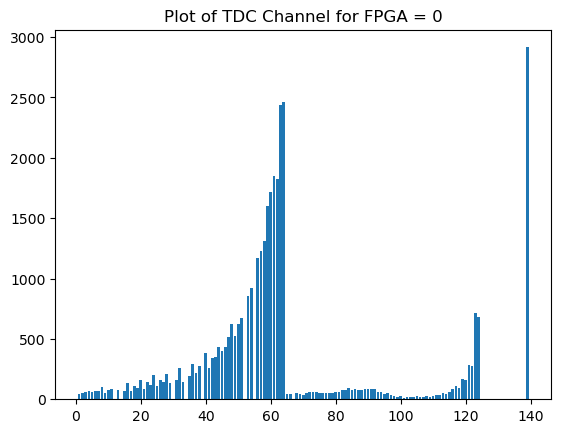

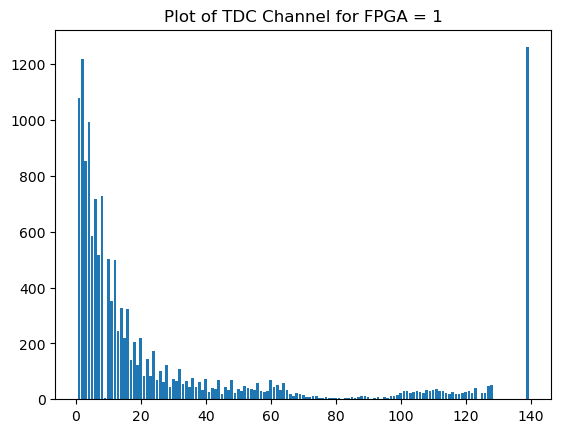

In [28]:
import matplotlib.pyplot as plt

FPGA_1 = df[df["FPGA"]==1]
FPGA_0 = df[df["FPGA"]==0]

# These lines calculate the "height" of each bar of the histogram
counts_0 = FPGA_0["TDC_CHANNEL"].value_counts()
counts_1 = FPGA_1["TDC_CHANNEL"].value_counts()

plt.bar(counts_0.index, counts_0.values)
plt.title("Plot of TDC Channel for FPGA = 0")
plt.show()

plt.bar(counts_1.index, counts_1.values)
plt.title("Plot of TDC Channel for FPGA = 1")
plt.show()

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

In [42]:
# Groupby = split df into many Series using TDC_CHANNEL
# size = calculate the size of every Series, to find the ones with most counts
# sort_values(ascending=False) = sorting values into descending order
# head(3) = selecting the first three lines
# list(...index) = putting the first three TDC_CHANNELs in a list 
top_channels_0 = list((FPGA_0.groupby("TDC_CHANNEL").size().sort_values(ascending=False).head(3)).index)
top_channels_1 = list((FPGA_1.groupby("TDC_CHANNEL").size().sort_values(ascending=False).head(3)).index)

print(f"The top 3 noisiest channels are: {top_channels_0} for FPGA = 0 and {top_channels_1} for FPGA = 1")

The top 3 noisiest channels are: [139, 64, 63] for FPGA = 0 and [139, 2, 1] for FPGA = 1


9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [41]:
tdc = df[df["TDC_CHANNEL"]==139]
unique_orbits = tdc["ORBIT_CNT"].unique()
print(unique_orbits)

[3869200167 3869200168 3869200169 3869200170 3869200171 3869200172
 3869200173 3869200174 3869200175 3869200176 3869200177 3869200178
 3869200179 3869200180 3869200181 3869200182 3869200183 3869200184
 3869200185 3869200186 3869200187 3869200188 3869200189 3869200190
 3869200191 3869200192 3869200193 3869200194 3869200195 3869200196
 3869200197 3869200198 3869200199 3869200200 3869200201 3869200202
 3869200203 3869200204 3869200205 3869200206 3869200207 3869200208
 3869200209 3869200210 3869200211 3869200212 3869200213 3869200214
 3869200215 3869200216 3869200217 3869200218 3869200219 3869200220
 3869200221 3869200222 3869200223 3869200224 3869200225 3869200226
 3869200227 3869200228 3869200229 3869200230 3869200231 3869200232
 3869200233 3869200234 3869200235 3869200236 3869200237 3869200238
 3869200239 3869200240 3869200241 3869200242 3869200243 3869200244
 3869200245 3869200246 3869200247 3869200248 3869200249 3869200250
 3869200251 3869200252 3869200253 3869200254 3869200255 386920